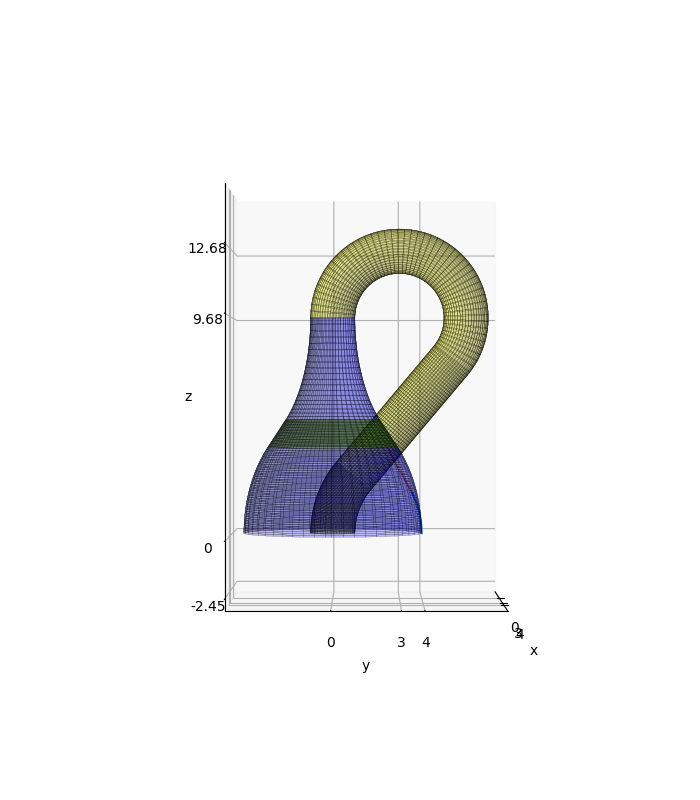

In [1]:

import numpy as np

import matplotlib.pyplot as plt
%matplotlib ipympl

#Rounding
dp=2

#Parameters
p = 1 #pipe thickness
a = 3
b = 4
e = 4 #.5*width

theta = .7
phi = .5

h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
d = -np.sqrt(e*(e-p)/2)
c = (h*np.sin(phi)+p*np.cos(phi)-e)/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),h-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

X = np.array([0,e*np.cos(phi),e*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])

#Figure
fig = plt.figure(figsize = (7,8), label = ' ')
fig.tight_layout()
ax = plt.axes(projection='3d')

#Bottle 1
u = np.linspace(0, e*np.sin(phi), 50)
ax.plot(0,np.sqrt(e**2-u**2),u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,0,u)

#ON Frame
T = (0,0,1)
N = (1,0,0)
B = (0,1,0)

#Radius function
r = np.sqrt(e**2-u**2)
rdot = -u/np.sqrt(e**2-u**2)

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)


#Bottle 2
u = np.linspace(e*np.sin(phi), h-c*np.sin(phi), 40)
ax.plot(0,e/np.cos(phi)-u*np.tan(phi),u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,0,u)

#ON Frame
T = (0,0,1)
N = (1,0,0)
B = (0,1,0)

#Radius function
r = e/np.cos(phi)-u*np.tan(phi)
rdot = -np.tan(phi)

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'tab:green', edgecolor = 'black', linewidth = .1, alpha = .25)

#Bottle 3
u = np.linspace(h-c*np.sin(phi), h, 20)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,0,u)

#ON Frame
T = (0,0,1)
N = (1,0,0)
B = (0,1,0)

#Radius function
r = p+c-np.sqrt(c**2-(u-h)**2)
rdot = (u-h)/np.sqrt(c**2-(u-h)**2)

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)


#Handle 1
u = np.linspace(0, a*(np.pi+theta), 100)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,a*(1+np.cos(np.pi-u/a)),h+a*np.sin(np.pi-u/a))

#ON Frame
T = (0,-np.sin(np.pi-u/a),np.cos(np.pi-u/a))
N = (0,-np.cos(np.pi-u/a),-np.sin(np.pi-u/a))
B = (1,0,0)

#Radius function
r = p
rdot = 0

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'yellow', edgecolor = 'black', linewidth = .1, alpha = .25)

#Handle 2
u = np.linspace(0, magPQ, 50)
v = np.linspace(0,2*np.pi,50)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0, (u/magPQ)*Q[1] + (1-u/magPQ)*P[1], (u/magPQ)*Q[2] + (1-u/magPQ)*P[2])
#ax.plot(0,(u/magPQ)*Q[0] + (1-u/magPQ)*P[0], (u/magPQ)*Q[1] + (1-u/magPQ)*P[1], (u/magPQ)*Q[2] + (1-u/magPQ)*P[2])

#ON Frame
T = (0,PQhat[1],PQhat[2])
N = (0,PQhat[2],-PQhat[1])
B = (1,0,0)

#Radius function
r = p
rdot = 0

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'yellow', edgecolor = 'black', linewidth = .1, alpha = .25)

#Handle 3
u = np.linspace(0, b*theta, 100)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,b+b*np.cos(np.pi-theta+u/b), b*np.sin(np.pi-theta+u/b))

#ON Frame
T = (0,-np.sin(np.pi-theta+u/b),np.cos(np.pi-theta+u/b))
N = (0,-np.cos(np.pi-theta+u/b),-np.sin(np.pi-theta+u/b))
B = (1,0,0)

#Radius function
r = p
rdot = 0

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'yellow', edgecolor = 'black', linewidth = .1, alpha = .25)

#Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set(xlim=(-1.5*a,2.5*a), ylim=(-1.5*a,2.5*a), zlim=(1.2*d,1.2*(h+a)))

#Ticks

if b<=a:
    ax.set_xticks([0,b,a], labels=["0", str(b), str(a)])
    ax.set_yticks([0,b,a], labels=["0", str(b), str(a)])
else:
    ax.set_xticks([0,a,b], labels=["0", str(a), str(b)])
    ax.set_yticks([0,a,b], labels=["0", str(a), str(b)])

ax.set_zticks([d, 0,h,h+a], labels=[str(np.round(d,dp)), "0", str(float(np.round(h,dp))), str(float(np.round(h+a,dp)))])

ax.set_aspect('equal')

ax.view_init(elev=0, azim=0, roll=0)

plt.show()

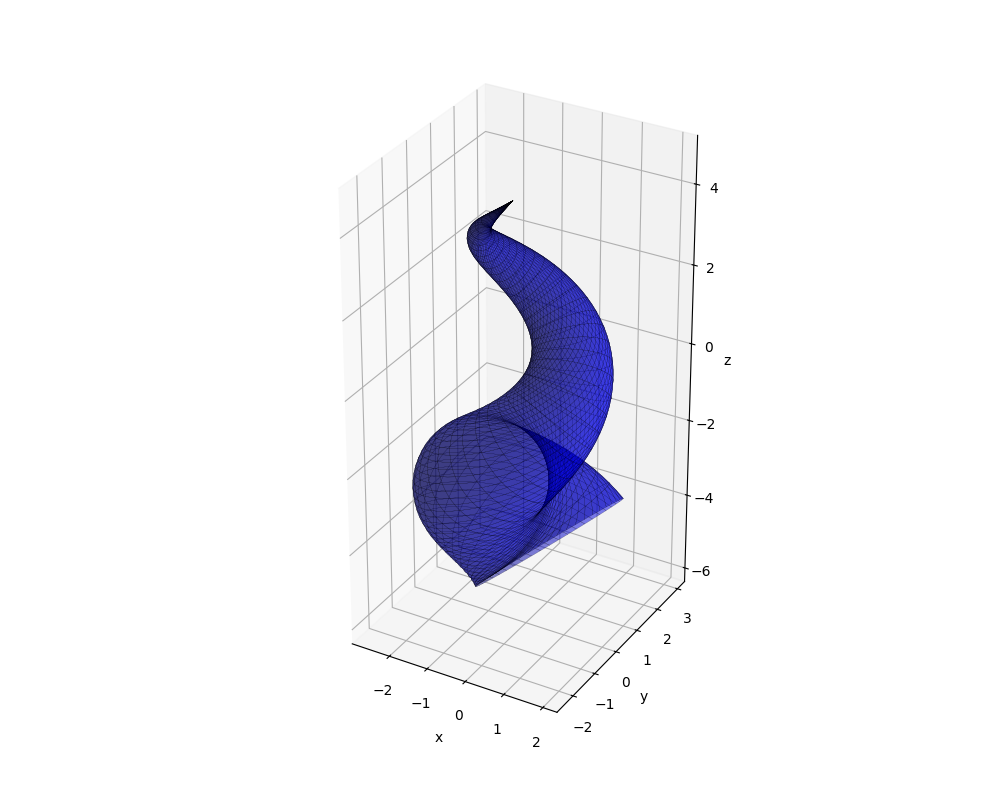

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

fig = plt.figure(figsize = (10,8), label = ' ')
ax = plt.axes(projection='3d')

u = np.linspace(-7, 7, 100)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

sqrt2 = np.sqrt(2)

#Diretrix
gamma = (np.cos(u/sqrt2), np.sin(u/sqrt2), u/sqrt2)

#ON Frame
T = ((-1/sqrt2)*np.sin(u/sqrt2),1/sqrt2*np.cos(u/sqrt2),1/sqrt2)
N = (-np.cos(u/sqrt2),-np.sin(u/sqrt2),0)
B = ((1/sqrt2)*np.sin(u/sqrt2),-(1/sqrt2)*np.cos(u/sqrt2),1/sqrt2)

#Radius function
r = 1-u/7
rdot = -1/7

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .5)

#Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set_aspect('equal')

plt.show()